# **Samuel Santiago Pinzón Reina**
# **Ingeniería de sistemas**

# Qué factores tuvieron más influencia sobre la sobrevivencia de los pasajeros del Titanic?






**Contexto**: Usted es un análista de datos en una empresa de seguros, que está revisando si los datos de pasajeros del Titanic podría ayudarle a entender que características ofrecían mejores chances de sobrevivir a este tipo de tragedias.

**Problema**: Entender cuáles factores tuvieron más impacto en la sobrevivencia de los pasajeros del Titanic.

Para realizar su trabajo, utilizará el archivo [`titanic.csv`](https://paste.c-net.org/GoodbyesRefill) con datos de los pasajeros del Titanic.

El archivo contiene las siguientes columnas:

|Variable|Significado|Valores|
|---|---|---|
|PassengerId|Identificación del Pasajero|#|
|Survived|Sobrevivió o No?|0=No, 1=Si, vacío=No se sabe|
|Pclass|Clase|1=1ra, 2=2da, 3=3ra|
|Name|Nombre|incluye el Título|
|Sex|Sexo|male, female|
|Age|Edad|en Años|
|SibSp|Hermanos + Conyuge|viaja con hermanos y/o conyuge|
|Parch|Hijos + Padres|viaje con hijos y/o padres|
|Ticket|Número de Tiquete|quienes viajan juntos tienen el mismo tiquete|
|Fare|Tarifa (Costo)|$|
|Cabin|Número de Cabina|indica la Cubierta donde se ubica la Cabina|
|Embarked|Puerto de Embarque|C=Cherbourg, Q=Queenstown, S=Southampton|

In [ ]:
# módulos estándar
import numpy as np
import pandas as pd

In [5]:
# módulos de visualización
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
#Estilo de gráfico para que sea más bonito:
plt.style.use("ggplot")

In [7]:
# cargar el dataframe con los datos
df = pd.read_csv('https://paste.c-net.org/GoodbyesRefill')

##**1.** Realicemos un EDA ([Exploratory Data Analysis](https://www.itl.nist.gov/div898/handbook/eda/eda.htm)) para comenzar a entender los datos.

In [8]:
# veamos la lista de variables del dataframe
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [9]:
# qué datos tenemos en el dataframe?
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
1305,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
1306,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
1307,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [10]:
# qué puede decir acerca de los datos en el dataframe?
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
dtypes: float64(3), int64(4), object(5)
memory usage: 122.8+ KB


Ahora utilicemos las herramientas estadísticas básicas para ver que descubrimos:

In [11]:
#Estadisticos principales de las variables númericas
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,1309.000000,891.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000
mean,655.000000,0.383838,2.294882,29.881138,0.498854,0.385027,33.295479
std,378.020061,0.486592,0.837836,14.413493,1.041658,0.865560,51.758668
min,1.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,328.000000,0.000000,2.000000,21.000000,0.000000,0.000000,7.895800
50%,655.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,982.000000,1.000000,3.000000,39.000000,1.000000,0.000000,31.275000
max,1309.000000,1.000000,3.000000,80.000000,8.000000,9.000000,512.329200


- El 50% de la población era mayor o menor de 28 años
- 1 de cada 4 pasajeros eran niños
- Hubo alguien que viajó con 9 acompañantes
- La variación del precio de los tiquetes era mucha. Se puede ver por la desviación estándar

In [12]:
# agrupemos los sobrevivientes por diferentes variables, y veamos la descripción
df.groupby("Survived")["Sex"].describe()

,count,unique,top,freq
Survived,,,,
0.0,549,2,male,468
1.0,342,2,female,233


- De la primera fila se puede decir que de 549 personas que no sobrevivieron, 468 fueron hombres, y 81 mujeres
- De la segunda fila podemos decir que de 342 personas que sobrevivieron, 233 fueron mujeres y 109 hombres

In [13]:
# Conocer loss estadisticos de la variable edad, teniendo en cuenta los grupos de sobrevivientes y no sobrevivientes.
df.groupby("Survived")["Age"].describe()

,count,mean,std,min,25%,50%,75%,max
Survived,,,,,,,,
0.0,424.0,30.626179,14.172110,1.00,21.0,28.0,39.0,74.0
1.0,290.0,28.343690,14.950952,0.42,19.0,28.0,36.0,80.0


- **Si los rangos de datos son muy parecidos no sirven para ser tenidos en cuenta**
- **La edad no es un factor determinante para definir la supervivencia**

In [14]:
# contar en que puerto se subieron las personas
df.groupby("Embarked")["PassengerId"].count()

Embarked
C    270
Q    123
S    914
Name: PassengerId, dtype: int64

- Como podemos ver la gran mayoría de pasajeros se subió en el puerto de Southampton

In [15]:
# Saber las proporciones de muertos y sobrevivientes, según el puerto de embarque
df.groupby("Survived")["Embarked"].describe()

,count,unique,top,freq
Survived,,,,
0.0,549,3,S,427
1.0,340,3,S,217


Con este breve análisis, ¿qué podemos decir acerca de los datos?

**R/** Con toda la información que pudmos mirar, podemos decir varias cosas:
- La mayoría de supervivientes fueron las mujeres, mientras que los hombres fueron los que más murieron.
- Otra cosa que resaltó es que la edad no importó mucho como un factor para la supervivencia. Esto debido a que la media de edad entre muertos y sobrevivientes es casi la misma, lo cual no representa información relevante para esa hipotesis.
-  Una gran parte de quienes se subieron al barco, lo hicieron en el puerto de Southampton
- La mayoría de muertos y de supervivientes se embarcaron en el puerto de Southampton

In [16]:
# cálcule algunas medidas estadísticas:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,1309.000000,891.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000
mean,655.000000,0.383838,2.294882,29.881138,0.498854,0.385027,33.295479
std,378.020061,0.486592,0.837836,14.413493,1.041658,0.865560,51.758668
min,1.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,328.000000,0.000000,2.000000,21.000000,0.000000,0.000000,7.895800
50%,655.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,982.000000,1.000000,3.000000,39.000000,1.000000,0.000000,31.275000
max,1309.000000,1.000000,3.000000,80.000000,8.000000,9.000000,512.329200


In [17]:
#Conocer cuantos datos nulos hay en cada columna
df.isnull().sum()

PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
dtype: int64

Hasta ahora qué puede decir acerca de los datos?

**R/** Algo que podemos notar a simple vista es que no todas las columnas nos dan información en cuanto sacamos sus estadísticas principales, como es el caso de las columnas ```PassengerId```, ```Pclass```, ```SibSp``` y ```Parch```. Ya que, a pesar de ser númericas, representan más que todo a una variable ordinal, excepto para ```PassangerId``` que es una variable discreta, ya que con esa columna se identifican a los pasajeros por su número de tiquete.

Más especificamente de las columnas podemos ver que las columnas de ```Age``` y ```Fare``` contienen datos muy dispersos, esto se ve tanto en su desviación estándar, como en la gran diferencia que hay entre sus cuartiles y sus valores máximos.

Y otra cosa que podemos ver en los datos, es que solo hay 5 columnas con datos nulos, y por encima de eso también se pueden ver que son pocos los datos que faltan (excepto por la columna ```Cabin```), lo cual nos sirve conocer para empezar a pensar una forma de llenar esos datos vacíos.

##**2.** Continuemos el [EDA](http://analyticsvidhya.com/blog/2020/08/exploratory-data-analysiseda-from-scratch-in-python/) utilizando las herramientas gráficas a nuestra disposición.

<Axes: xlabel='Survived'>

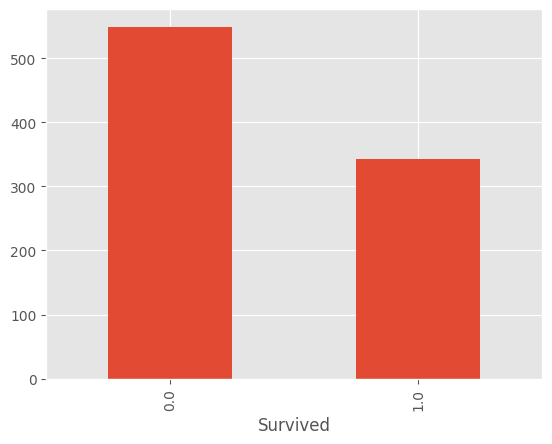

In [18]:
# comencemos con gráficos de barras con la frecuencia de los valores
df["Survived"].value_counts().plot(kind = "bar")

<Axes: xlabel='Sex'>

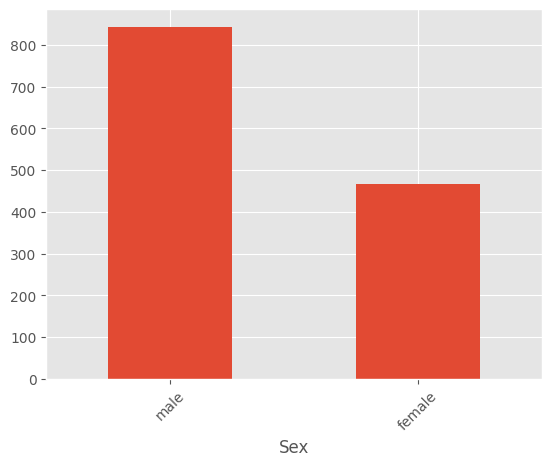

In [19]:
#Distribución de hombres y mujeres en los datos.
df["Sex"].value_counts().plot(kind = "bar", rot = 45)

<Axes: xlabel='Embarked'>

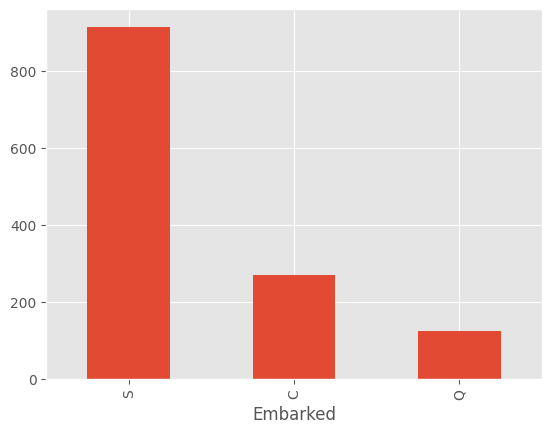

In [20]:
#Distribución de las personas que se embarcaron en distintos puertos
df["Embarked"].value_counts().plot(kind = "bar")

<Axes: xlabel='Pclass'>

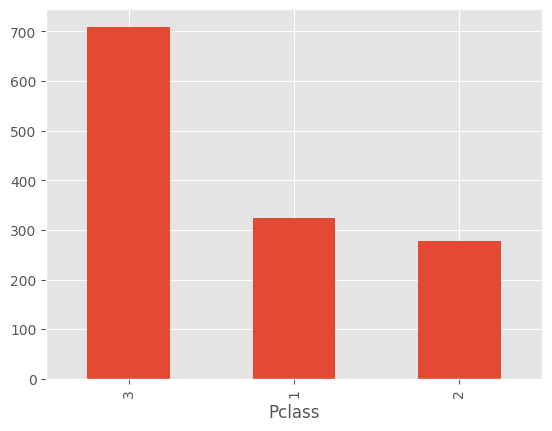

In [21]:
# Cantidad de personas que estuvieron en 1ra, 2da y 3ra clase
df["Pclass"].value_counts().plot(kind = "bar")

<Axes: xlabel='SibSp'>

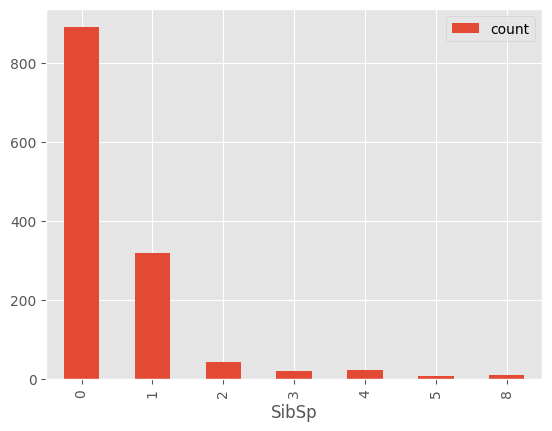

In [22]:
# Cantidad de personas que vinieron con su hermano/a o su esposa/o.
df2 = pd.DataFrame(df["SibSp"].value_counts())
df2.sort_values(by = ["SibSp"], ascending = True).plot(kind = "bar")

<Axes: xlabel='Parch'>

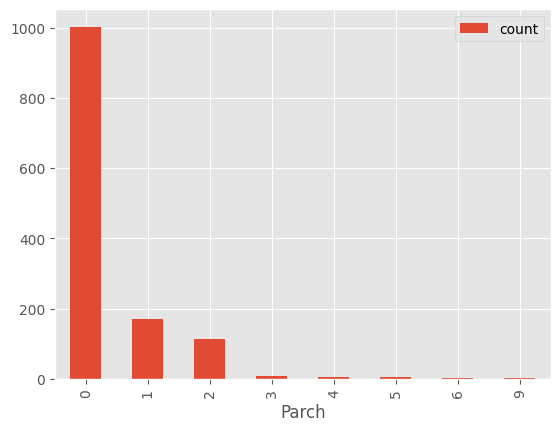

In [23]:
# Número de personas que viajaron acompañadas por sus padres o hijos
df3 = pd.DataFrame(df["Parch"].value_counts())
df3.sort_values(by = ["Parch"], ascending = True).plot(kind = "bar")

Cómo ve las variables hasta el momento, algún _insight_ en particular?

**R/** Particularmente no vemos un insight, pero sí podemos ver cómo están distribuidas las columnas.
Podemos ver que la cantidad de muertos fue mucho mayor que la de supervivientes, lo cual es lógico e se puede intuir por la magnitud del accidente.

Como anteriormente se había dicho, hay más hombres que mujeres en el barco. Lo interesante es que hay casi el doble de hombres que de mujeres. Así como en el caso del puerto de embarque, en el que se puede ver que la gran mayoría de pasajeros se subió en el puerto de Southampton.

Con respecto a la distribución de pasajeros por clase, podemos ver que la clase donde hubo más pasajeros fue la tercera clase, seguida de la primera y la segunda. Lo cual me llama la atención para saber cómo se distribuye la cantidad de muertos por clase.

Y finalmente, tenemos las distribuciones de personas que viajaron acompañados por un familiar, el cual nos dice de primeras que la gran mayoría de las personas viajó sola, pero esto no lo sabremos hasta que hagamos el conteo por tiquetes, ya que de ahí sabremos cuántos pasajeros comparten tiquete y así saber el número de tiquetes.

Hacemos gráficos de barras pero con la diferencia de que esta vez cruzamos distintas varibles:

<Axes: xlabel='Pclass', ylabel='count'>

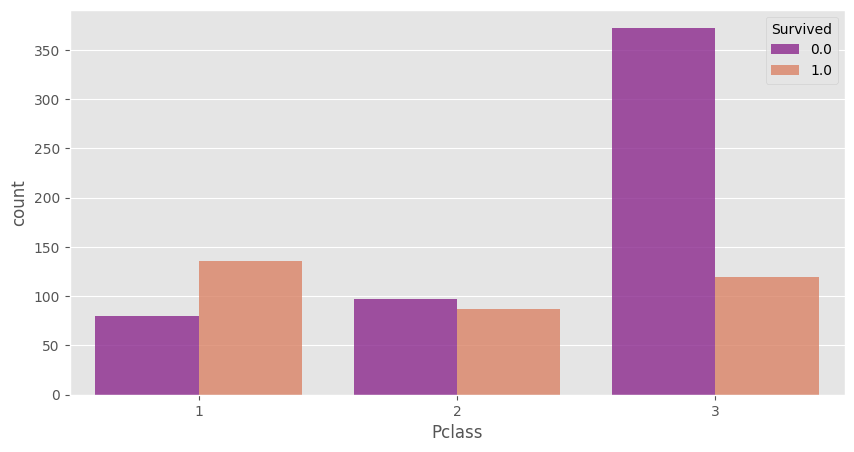

In [24]:
fig, ax = plt.subplots(figsize = (10, 5))
sns.countplot(ax = ax, data = df, x = "Pclass", hue = "Survived", palette = "plasma", alpha = 0.8)

<Axes: xlabel='Embarked', ylabel='count'>

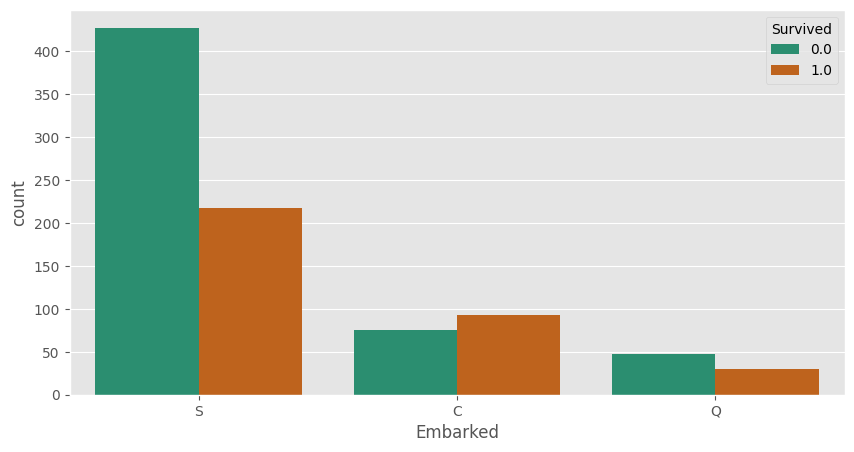

In [25]:
#Vemos cuantás personas de cada puerto sobrevivieron y murieron.
fig, ax = plt.subplots(figsize = (10,5))
sns.countplot(ax = ax, data = df, x = "Embarked", hue = "Survived", palette = "Dark2")

<Axes: xlabel='Parch', ylabel='count'>

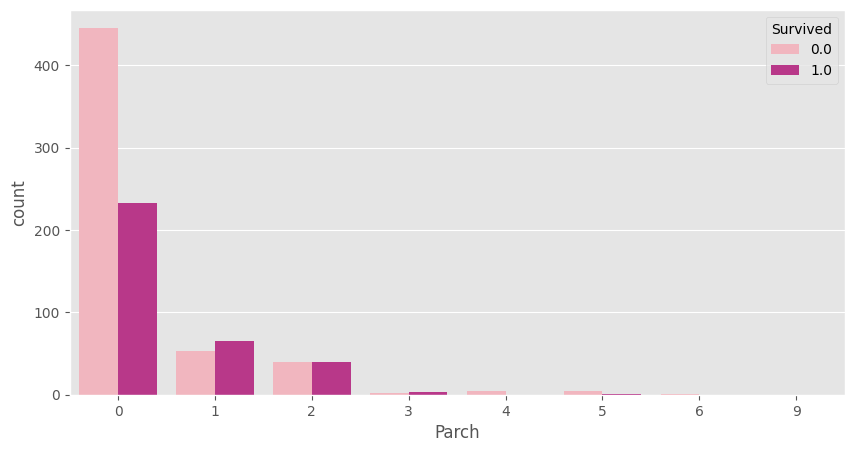

In [26]:
fig, ax = plt.subplots(figsize = (10,5))
sns.countplot(ax = ax, data = df, x = "Parch", hue = "Survived", palette = "RdPu")

<Axes: xlabel='SibSp', ylabel='count'>

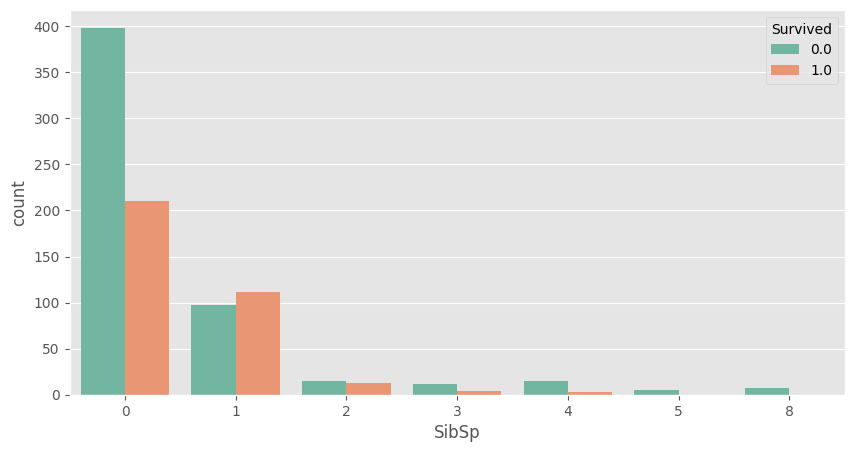

In [27]:
fig, ax = plt.subplots(figsize = (10,5))
sns.countplot(ax = ax, data = df, x = "SibSp", hue = "Survived", palette = "Set2")

<Axes: xlabel='Sex', ylabel='count'>

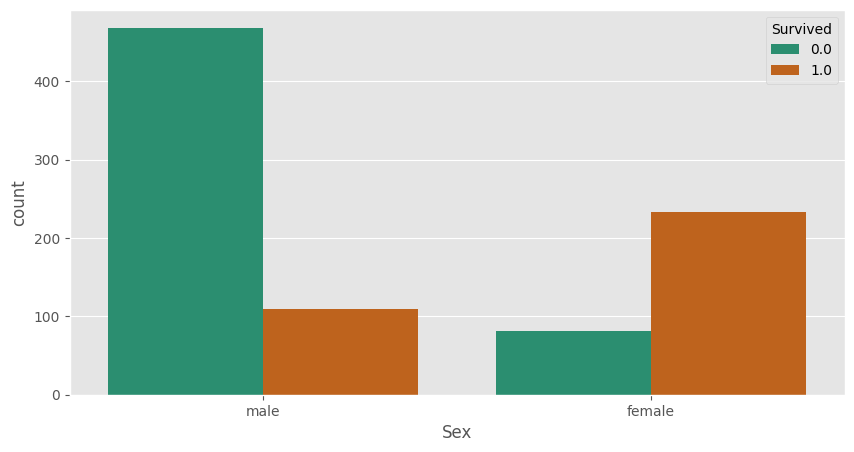

In [28]:
fig, ax = plt.subplots(figsize = (10,5))
sns.countplot(ax = ax, data = df, x = "Sex", hue = "Survived", palette = "Dark2")

Qué logró entender con los cruces entre variables?

**R/**
De lo primero que se puede ver en la primera gráfica es que la **mayoría de las personas que murieron estaban en tercera clase**, así como también que quienes estaban en primera clase tenían más probabilidad de sobrevivir que de morir, dado que hay una gran diferencia entre la cantidad de muertos y sobrevivientes en esta clase. Pero ya para la segunda clase vemos que la diferencia entre morir y sobrevivir es muy poca, y en el caso de la tercera la supervivencia era casi imposible, por lo que realmente estas dos clases no tienen un factor de importancia para la supervivencia de las personas, **todo lo contrario a la primera clase**.

Del segundo gráfico podemos ver que quienes se subieron en el puerto de **"Southampton" iban con más chances de morir**, que de sobrevivir, esto debido a que los muertos doblan en cantidad a quienes sobrevivieron. Y de los otros puertos es dificil decirlo, dado que la proporción de muertos y de vivos es casi la misma, pero aún así, esto nos indica que era **más facil sobrevivir para los que se subieron en los puertos de Queenstown y Cherbourg**, que los que se subieron en Southampton.

Ya para la tercera y cuarta gráfica podemos notar que quienes trajeron acompañantes (esposa, hijo/a(s), hermano/a(s), padres), **tenian menor dificultad para sobrevivir**, puesto que si vemos, quienes trajeron acompañantes tenían casi la misma probabilidad de sobrevivir que de morir, a diferencia de quienes no trajeron a nadie, dado que fueron más los muertos que no trajeron acompañantes, que los que sí trajeron, lo que significa que era más probable sobrevivir si se tenía un acompañante, que intentar sobrevivir pero sin acompañante.

Finalmente, tenemos la gráfica de los sobrevivientes segun su género, y de aquí podemos resaltar un factor que podría indicar la supervivencia de las personas, y es el género, ya que como podemos ver, **las mujeres fueron las que más se salvaron**, y no solo eso, sino que hay una gran diferencia entre las mujeres que murieron y las que no, por lo que podemos decir que **si se era mujer en ese barco, habían muchas más posibilidades para sobrevivir**.

<Axes: xlabel='Embarked', ylabel='Fare'>

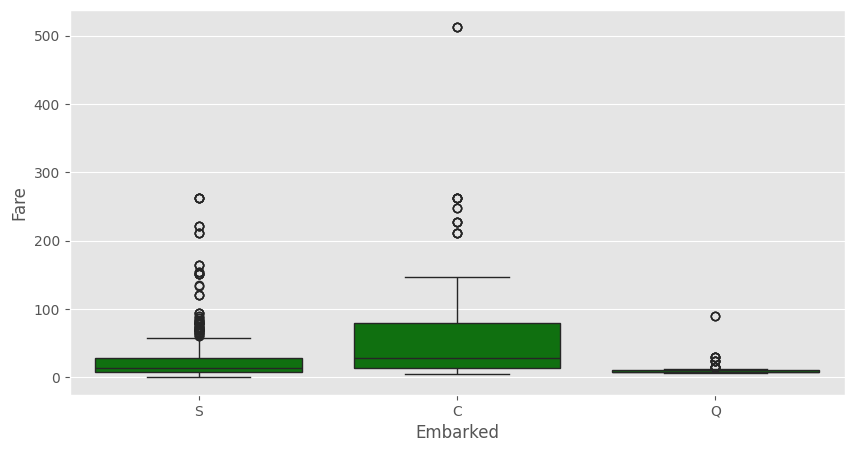

In [29]:
# veamos algunos boxplots de las variables (nos ayudan a identificar outliers)
#Precios del tiquete según el puerto de embarque
fig, ax = plt.subplots(figsize = (10,5))
sns.boxplot(data = df, y = "Fare", x = "Embarked", color = "green")

<Axes: xlabel='Pclass', ylabel='Age'>

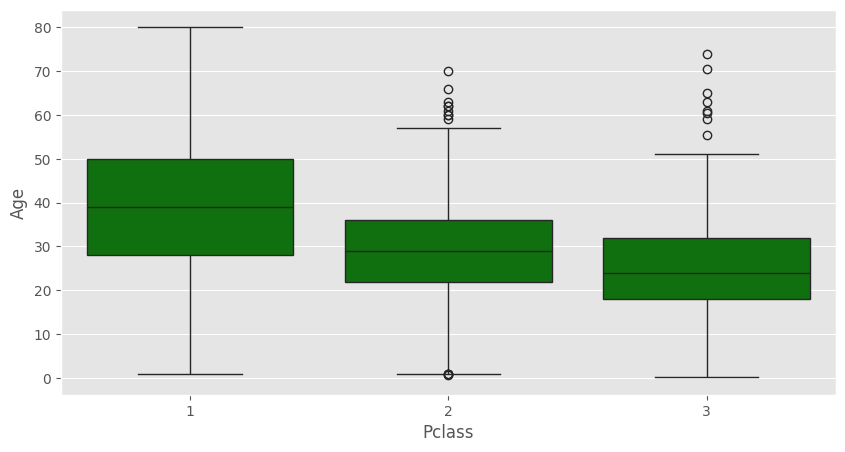

In [30]:
#gráfico de las edades según la clase en la que se subieron
fig, ax = plt.subplots(figsize = (10,5))
sns.boxplot(data = df, y = "Age", x = "Pclass", color = "green")

Los _boxplots_ le ayudaron a entender algo más?

**R/**
Sí. Anteriormente había dicho que los que se embarcaron en puertos diferentes al de Southampton tenían más chances de sobrevivir, y ahora que veo la gráfica de caja donde veo las tarifas de los boletos según el puerto. Esto se puede apreciar ya que quienes se subieron en el puerto de Cherbourg pagaron por los boletos más caros, por lo tanto eran de segunda o primera clase y, por tanto, tenían más probabilidades de sobrevivir.

Otra de las cosas que se pueden apreciar es el rango de edades por clase. A esto me refiero que, por ejemplo, en la tercera clase casi el 75% de personas eran personas por debajo de los 30 años, en segunda clase el 75% estaba debajo de los 40 años, y finalmente, en primera clase el 75% de las personas estaba por debajo de los 50 años de edad, lo que significaría que posiblemente una razón por la que la primera clase fue la que más sobrevivientes tuvo fue debido a que eran personas de la tercera edad y que eran personas que estaban por encima de la [expectativa de vida](https://ourworldindata.org/life-expectancy) en esa época.

<Axes: xlabel='Fare', ylabel='Age'>

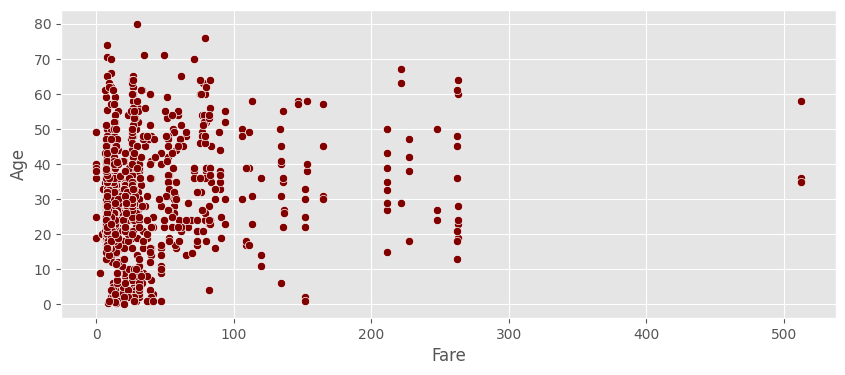

In [31]:
# los scatterplots también son útiles
fig, ax = plt.subplots(figsize = (10,4))
sns.scatterplot(data = df, x = "Fare", y = "Age", color = "Maroon")

<Axes: xlabel='Fare', ylabel='Survived'>

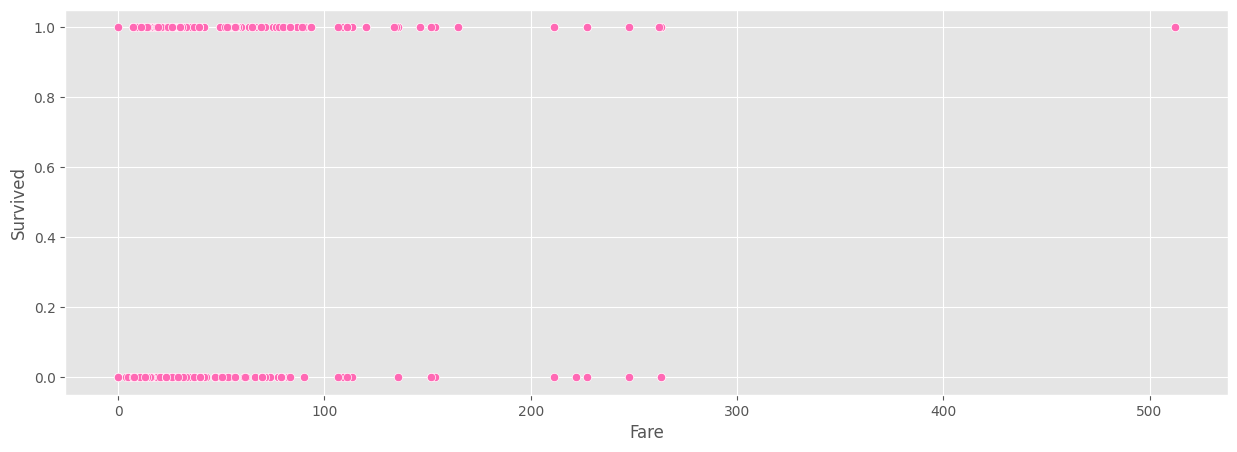

In [32]:
# ensaye con otros scatterpots:
fig, ax = plt.subplots(figsize = (15,5))
sns.scatterplot(data = df, x = "Fare", y = "Survived", color = "HotPink")

Fueron útiles los _scatterplots_, qué logró entender con ellos?

**R/**
Estas gráficas no nos muestran mucha información importanten o reveladora, dado que, por lo menos, en la segunda gráfica no se ve que haya relación entre el precio del tiquete y si pudo sobrevivir o no, esa persona, por lo que lo podemos descartar. Y del primer gráfico podemos decir que el grupo de edad entre los 30 años tuvieron una mayor cantidad de pasajeros que otros grupos de edad.

<Axes: xlabel='Age', ylabel='Count'>

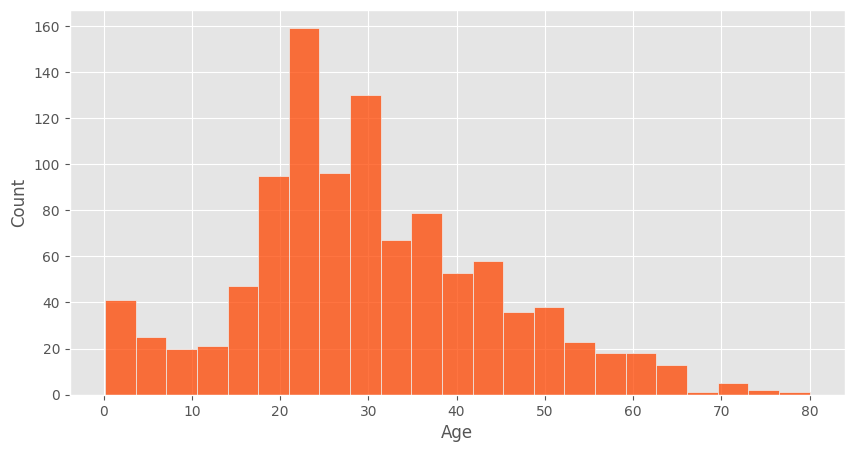

In [33]:
# ahora utilicemos un histograma para entender mejor la distribución de los datos
fig, ax = plt.subplots(figsize = (10,5))
sns.histplot(data = df, x = "Age", color = "OrangeRed")

<Axes: xlabel='Fare', ylabel='Count'>

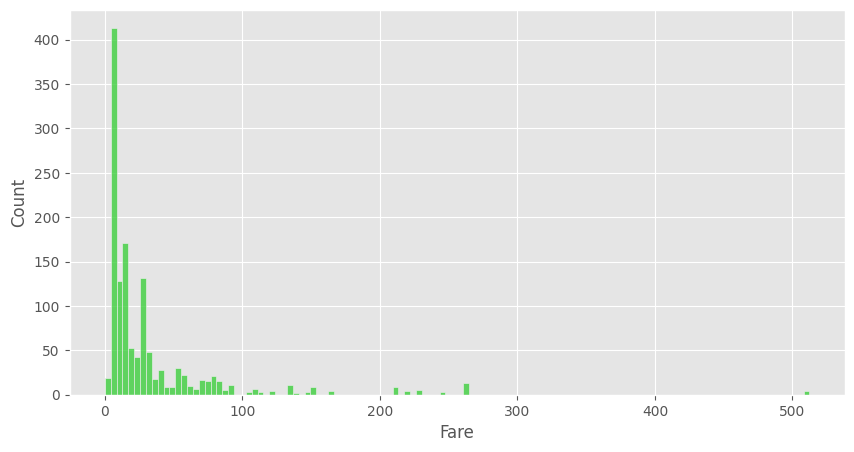

In [34]:
# revise los histogramas/distribuciones de otras variables
fig, ax = plt.subplots(figsize = (10,5))
sns.histplot(data = df, x = "Fare", color = "LimeGreen")

<Axes: xlabel='Age', ylabel='Count'>

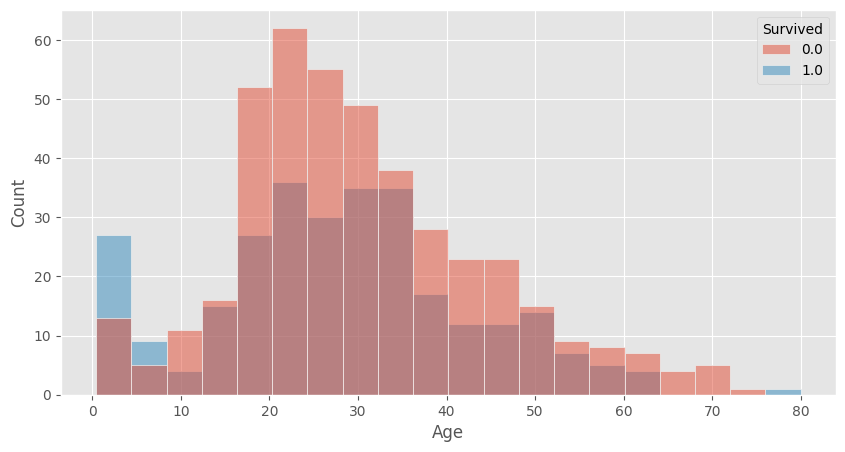

In [35]:
fig, ax = plt.subplots(figsize = (10,5))
sns.histplot(data = df, x = "Age", hue = "Survived")

Qué nuevo entendimiento de los datos logró gracias a los histogramas/distribuciones?

**R/**
De estos nuevos gráficos, se puede ver como se distribuyeron las edades y los costos de los pasajes entre pasajeros. En la primera gráfica vemos que las edades se distribuyeron de manera casi normal, y que la mayoría de pasajeros se encontraron entre las edades de 20 y 30 años. En la segunda gráfica vemos que la mayoría de pasajes comprados se compraron por menos de 100 libras, aproximadamente entre los 0 y 50 libras esterlinas.

Y en el último histograma vemos cómo fue la distribución de edades entre los sobrevivientes y los muertes. En donde podemos ver que la gráfica de los sobrevivientes inicia con valores altos, los cuales son los niños menores de 10 años, y nuevamente veremos que se eleva cuando llega al rango de edad entre los 20 y 40 años. Esto, en contraste con la distribución de quienes murieron, vemos que se distribuyen de manera casi similar, pero, más importante, que a pesar de que las eprsonas de tercera edad fueron priorizadas, la mayoría no sobrevivió.

Es muy usual que los datos no estén completos, veamos cómo están los datos del Titanic y veamos qué hacer al respecto.

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
dtypes: float64(3), int64(4), object(5)
memory usage: 122.8+ KB


Cuál es la mejor estrategia para completar los valores faltantes?

**R/**

Para la primera columna incompleta ```Survived```, la mejor estrategía es aplicar algún método o modelo de Machine Learning para que aprenda a identificar las probabilidades de supervivencia de la persona, el cual nos llenaría los datos y podríamos saber que tan acertado está en base a distintos cálculos que podemos hacer, como el error cuadratico medio o el absoluto.

Para los datos en ```Age```, la mejor estrategía es llenar los datos nulos con la media de edad, esto dado que hemos visto que no hay una relación con la edad y la supervivencia.

La tercera columna incompleta ```Fare``` hace falta un dato, por lo que teniendo en cuenta cuál es la moda se la podríamos asignar a ese valor faltante.

En la columna ```Cabin``` no sabría que se puede hacer, puesto que nos da muy poca información y no podemos generalizar los datos porque muchos de esos datos deben de ser diferentes.

Como última columna tenemos ```Embarked```, donde faltan dos datos, por lo que a esos datos se les puede asignar el nombre del puerto donde más gente se subió, el cual es el de Southampton.



Cómo se asegura que al adicionar los valores faltantes no se altera _el total_? es decir, se mantienen lo más parecidos a los datos reales.

**R/**

```Survived:``` Podemos asegurar que el modelo que se aplique hará aproximaciones bastante acercadas a los datos reales, dado que el modelo aprenderá con los datos que ya tenemos, por lo que los datos que nos devuelva serán bastante acercados.

```Age:``` Debido a que estariamos rellenando esta columna con la media de edad no afectariamos mucho esta columna en sí, ya que ese es el punto en el que están la mayoría de edades, por lo que el estadístico de esta columna no se afectaría.

```Fare:``` Como solo nos hace falta un dato, el cual no representa una gran cantidad de datos, podriamos asignarle el valor que más se repite, puesto que hay más posibilidades que ese haya sido el precio por el cual se compró el tiquete.

```Embarked:``` Acá podemos hacer lo mismo que en la anterior columna, y es conocer el puerto que más se repite y asignarle ese puerto a los dos valores que faltan, porque hay más probabilidad de que allá se haya subido ese pasajero.


##**3.** Antes de completar los datos faltantes, vamos a transformar un poco los datos:
- `Ticket` no es muy útil pero, si se repite nos indica cuantas persona viajan juntas (con el mismo tiquete).
- `Cabin` no dice mucho, pero la primera letra indica la cubierta en la que se encontraba (o desconocida).
- `Sex` podría convertirse a numérica: 0=`female`, 1=`male`
- `Embarked` también puede ser numérica: 0=`Cherbourg`, 1=`Queenstown`, 2=`Southampton`
- `Name` tampoco, pero se puede obtener el título de la persona: señor, señora, señorita,

###**3.1.** `Ticket` → `Contador`

In [37]:
#Realizamos un conteo de las personas que comparten ticket y la volvemos un dataframe aparte para poder contar la totalidad de veces que aparece un tiquete
acompañados = pd.DataFrame(df["Ticket"].value_counts(ascending= True))

#Volvemos a realizar el conteo, pero esta vez de las veces que se repitieron los tiquetes
acompañados.value_counts()

count
1        713
2        132
3         49
4         16
5          7
7          5
6          4
8          2
11         1
Name: count, dtype: int64

Cuántos pasajeros viajaban solos, y cuántos en grupo?

**R/** Hubo 713 pasajeros que viajaron solos, mientras que 596 personas viajaron en grupos desde 2 hasta 11 personas.

Cuántos grupos tenían 4 personas y cuántos grupos tenían 7 personas?

**R/** Hubo 16 grupos de **cuatro** personas y 5 grupos de **siete** personas.

###**3.2.** `Cabin` → `Cubierta`

In [38]:
#Contamos las veces que aparecen las distintas cabinas, y tomamos el indice de
cubierta = pd.DataFrame(df["Cabin"].value_counts())
cubierta = list(cubierta.index)

cabinas = []

#En una lista nueva, solo ingreso la primera letra de cada cabina.
for cabina in cubierta:
  cabinas.append(cabina[0])

#Para poder aplicar el método de conteo vuelvo la lista en un dataframe
cabinas = pd.DataFrame(cabinas)

cabinas.value_counts()

0
C    56
B    41
D    30
E    27
A    20
F    10
G     1
T     1
Name: count, dtype: int64

<Axes: xlabel='0'>

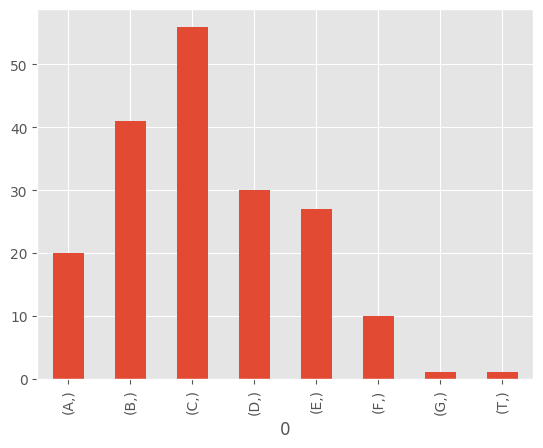

In [39]:
cabinas.value_counts().sort_index().plot(kind = "bar")

cómo interpreta estos datos?

**R/** El Titanic tenia 7 diferentes cabinas, ordenadas de la A a la G. Con los pocos datos que tenemos sobre la cabina, podemos ver que la cubierta donde más había gente eran las cabinas B, C y D, las cuales albergaban mayormente personas de primera clase.


###**3.3.** `Sex` → `Sex`

In [40]:
df.replace({"male": 1, "female": 0}, inplace= True)
df.head(5)

C:\Users\famil\AppData\Local\Temp\ipykernel_8804\1340419792.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({"male": 1, "female": 0}, inplace= True)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,S


###**3.4.** `Embarked` → `Embarked`

In [41]:
df.replace({"C": 0, "Q": 1, "S": 2}, inplace = True)
df.head(5)

C:\Users\famil\AppData\Local\Temp\ipykernel_8804\1996060319.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({"C": 0, "Q": 1, "S": 2}, inplace = True)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,2.0
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,0.0
2,3,1.0,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,2.0
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,2.0
4,5,0.0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,2.0


###**3.5.** `Name` → `Titulo`

In [42]:
titulos = []

for nombre in df["Name"]:
  if "Mr." in nombre:
    titulos.append("Mr")
  elif "Mrs." in nombre:
    titulos.append("Mrs")
  elif "Miss." in nombre:
    titulos.append("Miss")

titulos = pd.DataFrame(titulos)

In [43]:
titulos.rename(columns = {0: "Título"}, inplace = True)
titulos.value_counts()

Título
Mr        757
Miss      260
Mrs       197
Name: count, dtype: int64

##**4.** Vamos a completar los datos faltantes:

♦ Cuál es la estrategia para completar los datos de la edad?

**R/** Dado que hasta el momento hemos visto que la edad no representa un factor importante para la supervivencia de los pasajeros, llenaré los valores nulos de esta columna con la media de edad, así no altero los datos con edades aleatorias.

In [44]:
edad_media = df["Age"].mean()
edad_media

29.881137667304014

In [45]:
df["Age"].fillna(edad_media, inplace = True)

C:\Users\famil\AppData\Local\Temp\ipykernel_8804\836197810.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(edad_media, inplace = True)


In [46]:
cabina_faltantes = df["Cabin"].isnull().sum()
cabina_faltantes

1014

♦ Cuántos datos hacen falta en la columna Cabin?

**R/** Hacen falta 1014 datos en esta columna

In [47]:
embarked_faltantes = df["Embarked"].isnull().sum()
embarked_faltantes

2

Cuántos datos hacen falta en la columna Embarked?

**R/** Hacen falta solo dos datos

In [48]:
df['Embarked'].fillna(2, inplace= True)

C:\Users\famil\AppData\Local\Temp\ipykernel_8804\3163732567.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(2, inplace= True)


Cúal es la estrategia para completar los datos del puerto de embarque?

**R/**

Reemplazar todos los datos que sean de tipo ```nan``` por un 2, que representa el puerto de Southampton. Esto debido a que es el puerto en el cual más personas se subieron, y el que agregue dos personas más que se suban a este puerto no cambia mucho en el cómo se ven y see pueden interpretar lo gráficos.

Después de la conversión de valores, y completar los faltantes, hay columnas que no necesitamos.

In [49]:
df.drop(["Name", "Cabin", "PassengerId", "Ticket"], inplace = True, axis = 1)

In [50]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0.0,3,1,22.000000,1,0,7.2500,2.0
1,1.0,1,0,38.000000,1,0,71.2833,0.0
2,1.0,3,0,26.000000,0,0,7.9250,2.0
3,1.0,1,0,35.000000,1,0,53.1000,2.0
4,0.0,3,1,35.000000,0,0,8.0500,2.0
...,...,...,...,...,...,...,...,...
1304,NaN,3,1,29.881138,0,0,8.0500,2.0
1305,NaN,1,0,39.000000,0,0,108.9000,0.0
1306,NaN,3,1,38.500000,0,0,7.2500,2.0
1307,NaN,3,1,29.881138,0,0,8.0500,2.0


Llenamos los valores nulos de los precios del tiquete.

In [51]:
moda_precio = df["Fare"].mode()
moda_precio

0    8.05
Name: Fare, dtype: float64

In [52]:
df["Fare"].fillna(value = moda_precio, inplace = True)

C:\Users\famil\AppData\Local\Temp\ipykernel_8804\1166318096.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Fare"].fillna(value = moda_precio, inplace = True)


In [53]:
df["Fare"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1309 entries, 0 to 1308
Series name: Fare
Non-Null Count  Dtype  
--------------  -----  
1308 non-null   float64
dtypes: float64(1)
memory usage: 10.4 KB


------------------------------------------------------------

**5.** Ahora si, a analizar los datos.

Complete el análisis ...

Qué puede concluir?

**R/** Gracias a toda la información recopilada y análizada, se ha podido ver varios factores que afectaron en la supervivencia de los pasajeros:
- Uno de los primeros factores  que pudimos ver, fue la clase a la que pertenecían los pasajeros a bordo, ya que aquellos que estaban en primera clase tuvieron un nivel de supervivencia muy por encima de la cantidad de muertos que hubo de pasajeros de esa clase. Y de lo anterior, se desprende una suposición que tiene que ver con la edad. Porque viendo cómo se distribuían las edades por clase, se puede resaltar el hecho de que en primera clase el 75% de las personas tenían una edad con la cual se le podría decir que son personas de la tercera edad, es por esto que podríamos decir que varios pasajeros que estaban en primera clase tuvieron mejores posibilidades de sobrevivir gracias a su edad, pero no tengo suficientes evidencias para concluirlo.

  Pero aun así, lo que podemos afirmar es que aquellos que estaban en primera clase tenían tenían mucha más posibilidad de sobrevivir al naufragio.

- Otro factor que tuvo importancia, es el puerto en el que se embarcaron los pasajeros, ya que las gráficas nos apuntaron a que quieness subieron en el puerto de Southampton tenían posibilidades más altas de morir, a diferencia de los otros dos puertos, los cuales tuvieron niveles de superviviencia y de muertos más proporcionados.

- Ahora veremos uno de los factores más importantes, y es el género de la persona. Y es que todo nos indica que uno de los factores más importantes para la supervivencia de los pasajeros fue si eran hombres o mujeres, ya que la mayor cantidad de supervivientes del naufragio fueron mujeres, y, en ese mismo orden de ideas, fueron muy pocas mujeres que murieron. Y es por esto, que podemos afirmar que el ser mujer en ese barco, era un factor muy importante a la hora de sobrevivir.

Asi que para finalizar, podemos concluir que los tres factores que tenían influencia para la supervivencia de los pasajeros fueron la clase en la que estaban a bordo, el puerto en el que se subieron y el género de las personas. Ahora, a modo de ejercicio comprobaremos si esta hipótesis es verdadera, así que usando pandas buscaremos los datos que cumplan con estas condiciones y veremos si sobrevivieron o no.

In [54]:
#Ubicamos los indices de los datos que cumplan con las condiciones que pedíamos
selected_indices = df.loc[(df['Sex'] == 0) & (df['Pclass'] == 1) & (df['Embarked'] != 2)].index
selected_indices

Index([   1,   31,   52,  177,  194,  195,  215,  218,  256,  258,  291,  299,
        306,  307,  309,  310,  311,  319,  325,  329,  337,  366,  369,  375,
        380,  393,  412,  496,  513,  523,  537,  539,  556,  581,  591,  641,
        700,  710,  716,  742,  835,  842,  849,  879,  915,  917,  939,  950,
        965,  991, 1003, 1013, 1041, 1059, 1070, 1075, 1099, 1109, 1115, 1130,
       1131, 1163, 1205, 1234, 1241, 1255, 1259, 1262, 1266, 1288, 1293, 1302,
       1305],
      dtype='int64')

In [55]:
#Creamos un nuevo datadrame el cual solo tendrá los datos que cumplen las condiciones
df_factores = df.loc[ selected_indices ].reset_index(drop= True)
df_factores

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1.0,1,0,38.000000,1,0,71.2833,0.0
1,1.0,1,0,29.881138,1,0,146.5208,0.0
2,1.0,1,0,49.000000,1,0,76.7292,0.0
3,0.0,1,0,50.000000,0,0,28.7125,0.0
4,1.0,1,0,44.000000,0,0,27.7208,0.0
...,...,...,...,...,...,...,...,...
68,NaN,1,0,45.000000,0,0,262.3750,0.0
69,NaN,1,0,48.000000,1,1,79.2000,0.0
70,NaN,1,0,22.000000,0,1,59.4000,0.0
71,NaN,1,0,37.000000,1,0,90.0000,1.0


<Axes: xlabel='Survived', ylabel='count'>

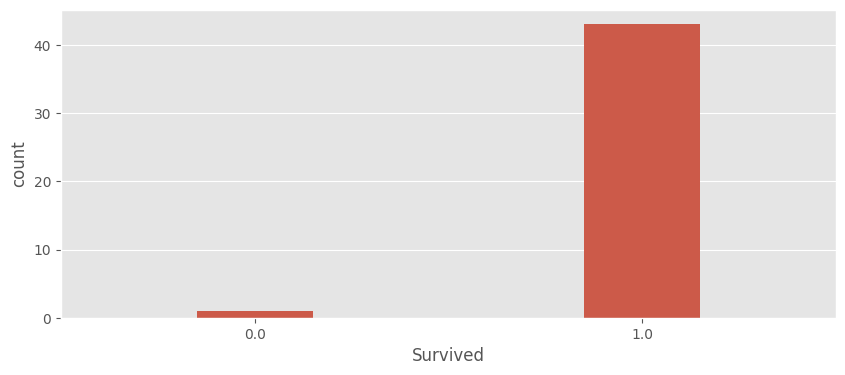

In [56]:
#Hacemos una gráfica que nos muestre la distribución de sobrevivientes y muertos en las personas cumplen las condiciones
fig, ax = plt.subplots(figsize = (10,4))
sns.countplot(data = df_factores, x = "Survived", width= 0.3)

<Axes: xlabel='Age', ylabel='Count'>

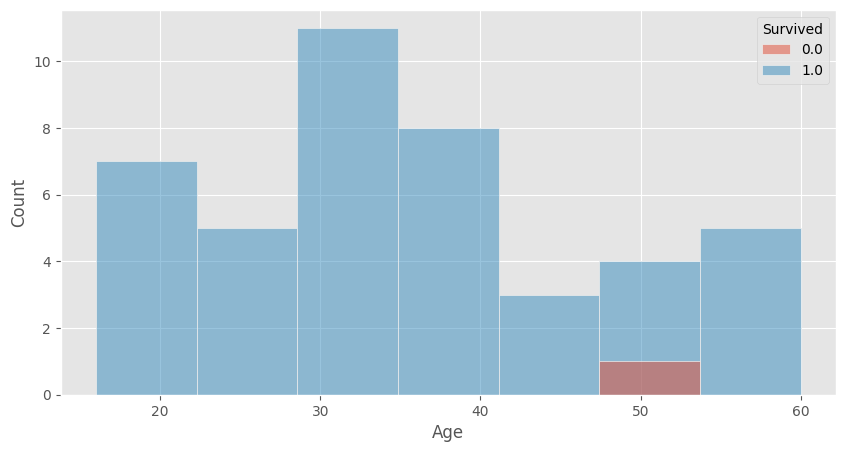

In [57]:
#Vemos la distribución de edades en las personas
fig, ax = plt.subplots(figsize = (10,5))
sns.histplot(data = df_factores, x = "Age", hue = "Survived")

Con estos resultados en las gráficas podemos comprobar y concluir que esos 3 factores sí tienen influencia en la spuervivencia de los pasajeros a bordo.